# Support Vector Machine (SVM) Algorithm

## Importing Required Libraries

In [1]:
# This cell loads all necessary libraries for data processing, model building (using SVM), evaluation, and visualization.
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Preprocessing

In [2]:
df = pd.read_csv("Airplane accidents severity.csv") # Load dataset
df = df.drop(columns=['Accident_ID']) # Drop the unique ID since it does not contribute to prediction

# Encode the target variable (Severity)
label_encoder = LabelEncoder()
df['Severity'] = label_encoder.fit_transform(df['Severity'])

# Split into features and target
X = df.drop(columns=['Severity']) # Features
Y = df['Severity'] # Target variable

# Train-test split (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# 'stratify=Y' ensures the class distribution is preserved in both sets.

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Tuning with Grid Search

In [3]:
# Define the grid of hyperparameters to search through
parameters = {
    'C': [0.1, 1, 10],  # Regularization strength
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernel types to test
    'gamma': ['scale', 'auto']  # Kernel coefficient for 'rbf' and 'poly'
}

# Perform grid search with cross-validation to find the best parameters
svm_grid = GridSearchCV(SVC(), parameters, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, Y_train) # Train on scaled training data

# Print best parameters
print("Best Parameters:", svm_grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## Training the SVM Model

In [4]:
# Train SVM model with best kernel and parameters
svm_model = SVC(kernel='rbf', C=10, random_state=42)
svm_model.fit(X_train_scaled, Y_train)

# Number of support vectors
num_support_vectors = len(svm_model.support_)
print(f"Number of support vectors: {num_support_vectors}")

Number of support vectors: 3253


## Model Evaluation 

Accuracy: 90.05%
Precision: 90.05%
Recall: 90.05%


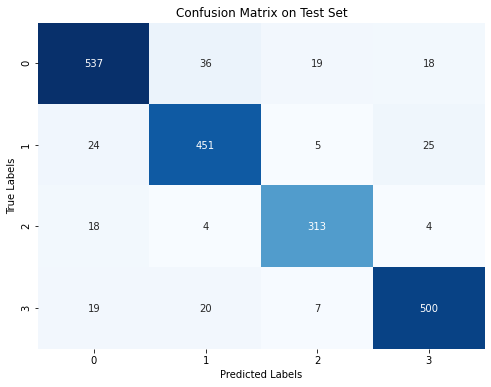

Classification Report:
                                          precision    recall  f1-score   support

              Highly_Fatal_And_Damaging       0.90      0.88      0.89       610
              Minor_Damage_And_Injuries       0.88      0.89      0.89       505
      Significant_Damage_And_Fatalities       0.91      0.92      0.92       339
Significant_Damage_And_Serious_Injuries       0.91      0.92      0.91       546

                               accuracy                           0.90      2000
                              macro avg       0.90      0.90      0.90      2000
                           weighted avg       0.90      0.90      0.90      2000



In [5]:
# Predict on the test set using the trained model
Y_pred = svm_model.predict(X_test_scaled)

# Compute evaluation metrics
conf_matrix = confusion_matrix(Y_test, Y_pred)
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average='weighted')
recall = recall_score(Y_test, Y_pred, average='weighted')

# Display results
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")

# Plot the confusion matrix
plt.figure(figsize= (8, 6))
sns.heatmap (conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted Labels") 
plt.ylabel("True Labels")
plt.show()

# classification report
class_report = classification_report(Y_test, Y_pred, target_names=label_encoder.classes_)
print('Classification Report:\n', class_report)

## Cross-Validation

In [6]:
cross_val = cross_val_score(svm_model, X_train_scaled, Y_train, cv=5)
print("Cross-validation scores:", cross_val)
print("Mean CV accuracy:", cross_val.mean())

Cross-validation scores: [0.915   0.8975  0.89125 0.9     0.89   ]
Mean CV accuracy: 0.8987499999999999
